Ant statistical testing.

- first, test for a difference in the time in open area; outside of the leaf starting zone.

- I take this approach due to the occlusions in the leaf box zone; for sanity, I check they are "equally" occulded in the leaf box; although the behaviors could be different...

In [37]:
from scipy.stats import mannwhitneyu


left_chamber = [29.03, 49.82, 45.69, 43.57, 21.54]
right_chamber = [19.31, 9.13, 6.08, 13.99, 3.8]


stat, p_value = mannwhitneyu(left_chamber, right_chamber, alternative='two-sided')

print("Mann-Whitney U test statistic:", stat)
print("P-value:", p_value)

# Interpretation
alpha = 0.05  # Threshold for significance
if p_value < alpha:
    print("There is a significant difference between the groups.")
else:
    print("There is no significant difference between the groups.")


Mann-Whitney U test statistic: 25.0
P-value: 0.007936507936507936
There is a significant difference between the groups.


In [39]:
# Calculate the mean for each group
mean_left_chamber = np.mean(left_chamber)
mean_right_chamber = np.mean(right_chamber)

mean_left_chamber, mean_right_chamber

(37.92999999999999, 10.462)

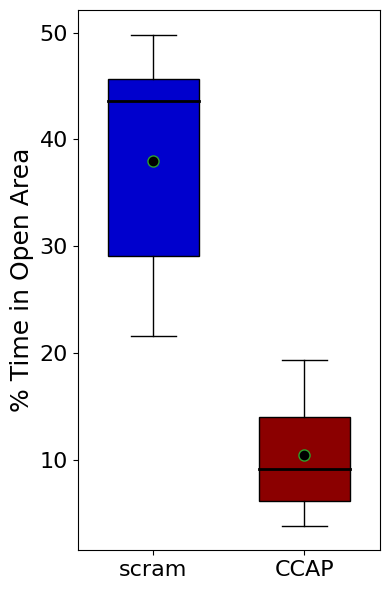

In [38]:
data = [left_chamber, right_chamber]
labels = ['scram', 'CCAP']

plt.figure(figsize=(4, 6))
bplot = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True, medianprops=dict(color="black"), widths=0.6)

# Setting colors for each box
colors = ['mediumblue', 'darkred']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# Customizing the median lines to be black
for median in bplot['medians']:
    median.set(color='black', linewidth=2)

# Customizing the mean points
for mean in bplot['means']:
    mean.set(marker='o', markerfacecolor='black', markersize=8)

# Set larger font sizes for labels and axis
plt.ylabel('% Time in Open Area', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Grid lines and tight layout for better spacing
#plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()


# Inside leaf zone;
- hypothesis is this should be similar due to poor tracking during occulsions...

In [41]:
from scipy.stats import mannwhitneyu


left_chamber =  [26.23, 25.19, 37.67, 29.08, 58.08]
right_chamber = [24.39, , 25.36, 50.56, 62.28]


stat, p_value = mannwhitneyu(left_chamber, right_chamber, alternative='two-sided')

print("Mann-Whitney U test statistic:", stat)
print("P-value:", p_value)

# Interpretation
alpha = 0.05  # Threshold for significance
if p_value < alpha:
    print("There is a significant difference between the groups.")
else:
    print("There is no significant difference between the groups.")


Mann-Whitney U test statistic: 9.0
P-value: 0.8857142857142857
There is no significant difference between the groups.


# Option 2:

IF we want to assume that the time when the ants cannot be tracked is WITHIN the leaf zone, we can:
- compute the "missing" %, add that % to the leaf zone, and recompute stats:


```
video 1,73.77,,,,video 1,80.69
video 2,50.18,,,,video 2,93.92
video 3,54.31,,,,video 3,93.92
video 4,56.43,,,,video 4,86.91
video 5,78.46,,,,video 5,96.12
```


In [42]:
from scipy.stats import mannwhitneyu


left_chamber = [73.77, 50.18, 54.31, 56.43, 78.46]
right_chamber = [80.69, 93.92, 93.92, 86.91, 96.12]


stat, p_value = mannwhitneyu(left_chamber, right_chamber, alternative='two-sided')

print("Mann-Whitney U test statistic:", stat)
print("P-value:", p_value)

# Interpretation
alpha = 0.05  # Threshold for significance
if p_value < alpha:
    print("There is a significant difference between the groups.")
else:
    print("There is no significant difference between the groups.")


Mann-Whitney U test statistic: 0.0
P-value: 0.0119252335930176
There is a significant difference between the groups.


In [45]:
# Calculate the mean for each group
mean_left_chamber = np.mean(left_chamber)
mean_right_chamber = np.mean(right_chamber)

mean_left_chamber, mean_right_chamber

(62.629999999999995, 90.31200000000001)

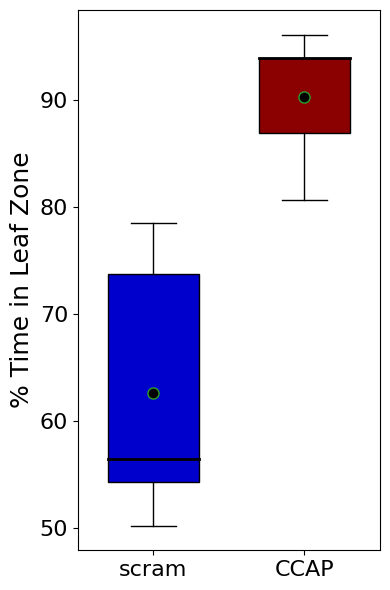

In [44]:
data = [left_chamber, right_chamber]
labels = ['scram', 'CCAP']

plt.figure(figsize=(4, 6))
bplot = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True, medianprops=dict(color="black"), widths=0.6)

# Setting colors for each box
colors = ['mediumblue', 'darkred']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

# Customizing the median lines to be black
for median in bplot['medians']:
    median.set(color='black', linewidth=2)

# Customizing the mean points
for mean in bplot['means']:
    mean.set(marker='o', markerfacecolor='black', markersize=8)

# Set larger font sizes for labels and axis
plt.ylabel('% Time in Leaf Zone', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Grid lines and tight layout for better spacing
#plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()
